In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()
# df.isnull()
# df.isnull().sum()
# df.info()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
# FEATURE ENGINEERING

#Age

df["Age"] = 2026 -df["Year_Birth"]

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [8]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date-df["Dt_Customer"]).dt.days

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [11]:
# Customer Joining Date

# Spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# Children

df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle" :"Undergraduate" , "Graduation":"Graduation", "Master":"Postgraduate","PhD":"Postgraduate"
})

In [13]:
# Marital_Status

df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner","Together": "Partner",
    "Single" : "Alone" , "Divorced" : "Alone",
    "Widow" : "Alone" , "Absurd" :"Alone", 
    "YOLO" : "Alone"
})
 
df["Living_With"].value_counts()


Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_children', 'Living_With'],
      dtype='object')

In [15]:
# Drop Columns

cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]

spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [16]:
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


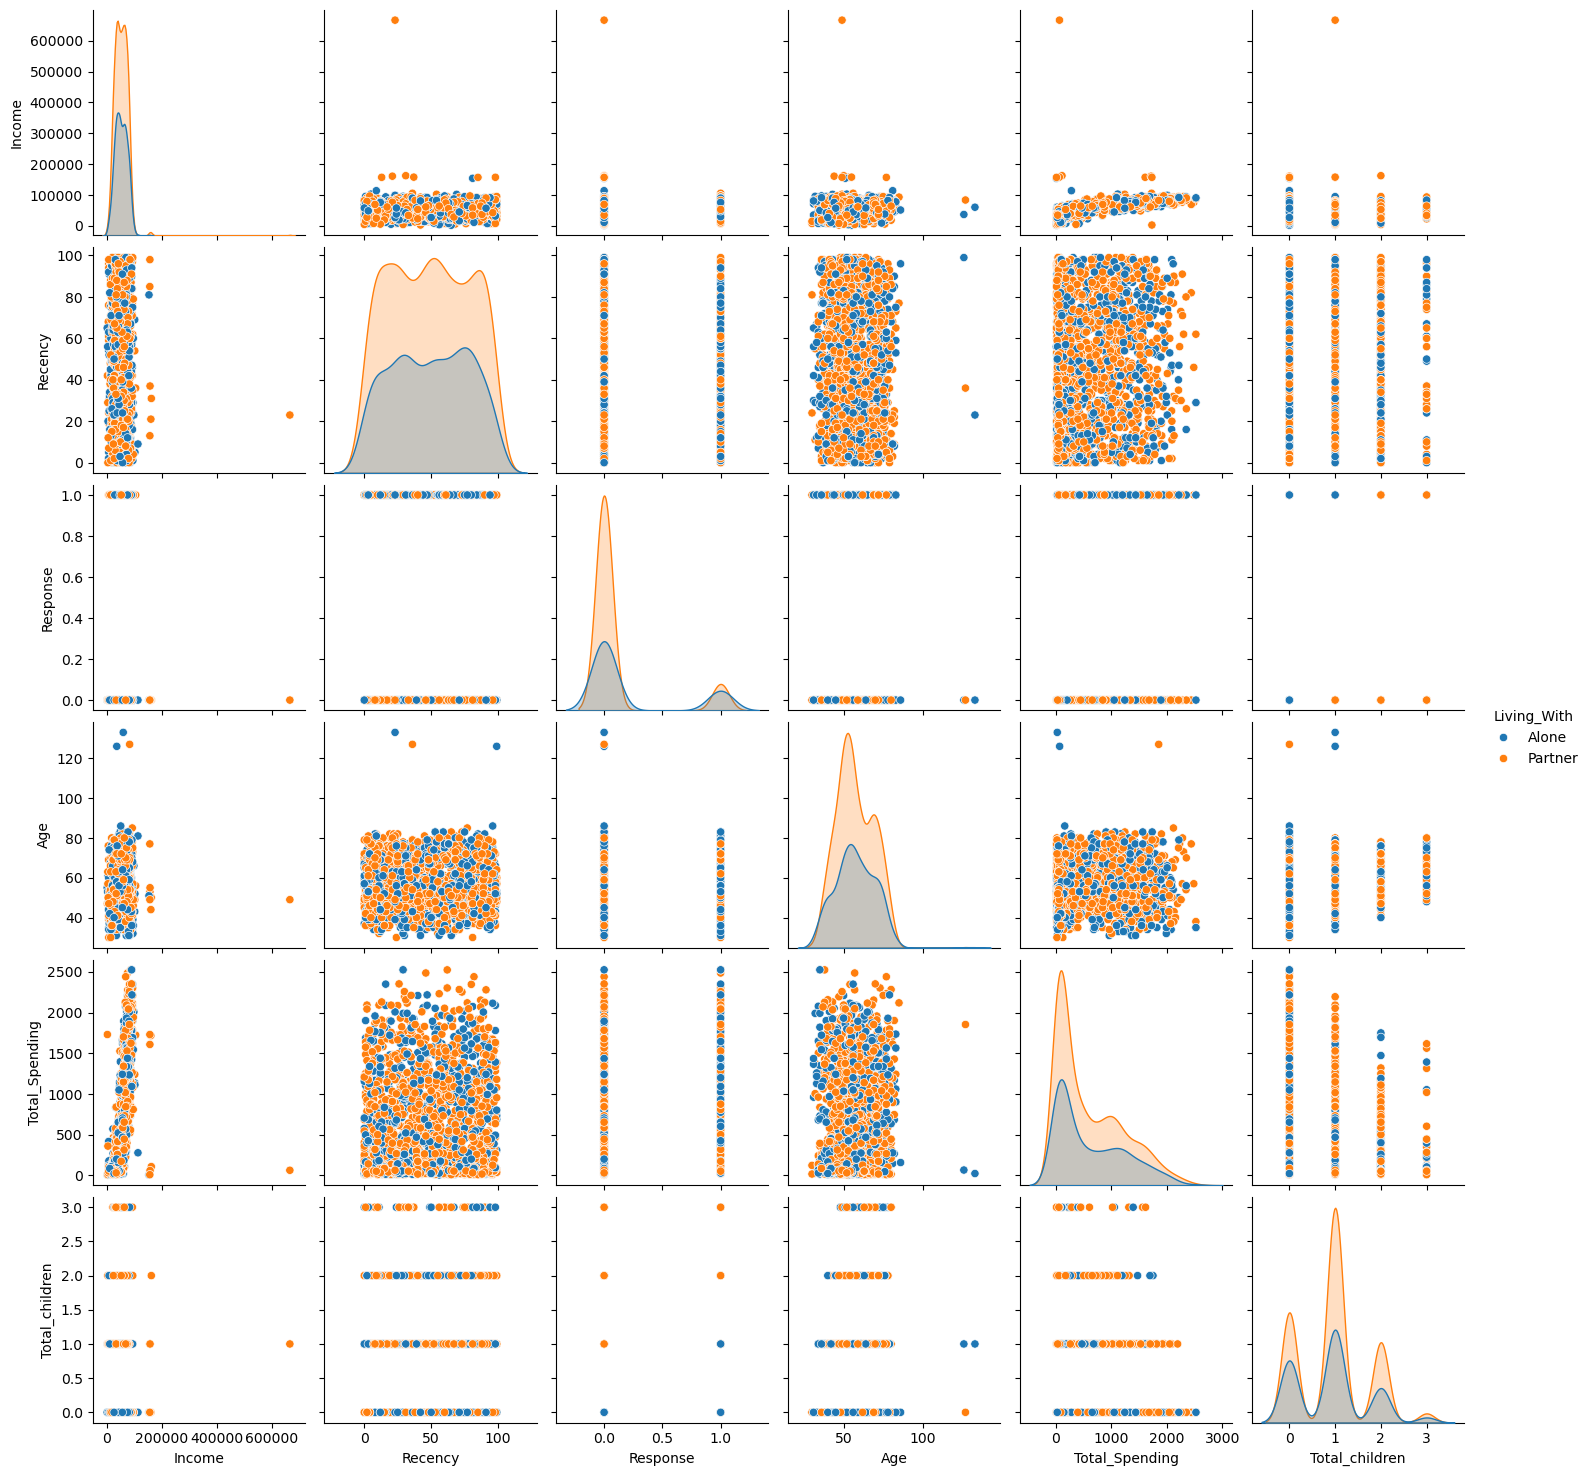

In [17]:
# OUTLIERS

cols = ["Income","Recency","Response","Age","Total_Spending","Total_children"]

# RELATIVE PLOTS OF SOME FEATURES - PAIR PLOTS
sns.pairplot(df_cleaned, vars=cols, hue="Living_With")

In [18]:
# Remove Outliers

print("data size with outiers : ",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]) < 90]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data size without outliers : ",len(df_cleaned))

data size with outiers :  2240
data size without outliers :  2212


<Axes: >

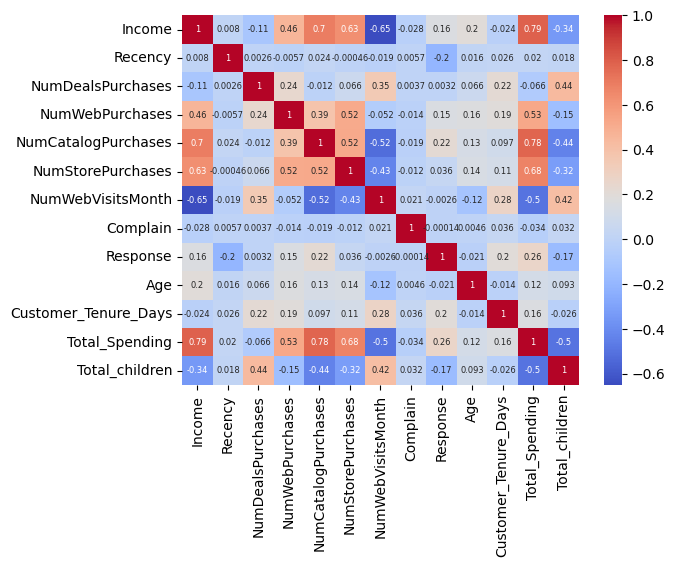

In [19]:
# Hear map

corr = df_cleaned.corr(numeric_only = True)

sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size" : 6},
    cmap = "coolwarm"
)

In [20]:
# Encoding

from sklearn.preprocessing import OneHotEncoder

one = OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = one.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns = one.get_feature_names_out(cat_cols),index=df_cleaned.index)

df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis = 1)

In [21]:
df_encoded.shape
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [22]:
# Scaling

from sklearn.preprocessing import StandardScaler

X = df_encoded

scaler = StandardScaler()

x_scaled = scaler.fit_transform(X)

In [23]:
# 2D 

from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

x_pca = pca.fit_transform(x_scaled)

pca.explained_variance_ratio_

array([0.23258254, 0.11390916, 0.10418299])

Text(0.5, 0.92, '3d Projection')

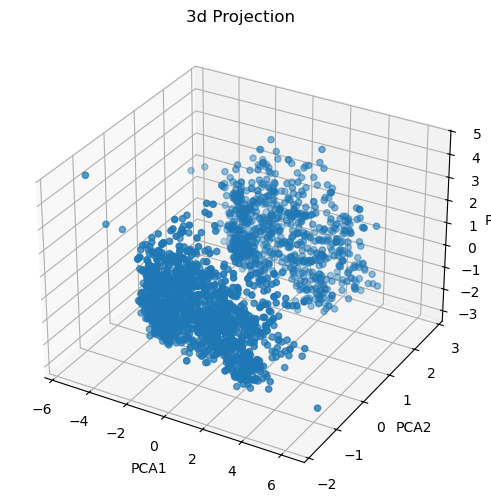

In [24]:
# plot 3D

fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0] , x_pca[:,1] , x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

In [25]:
# Analyze k value

# 1. Elbow Method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [26]:
knee = KneeLocator(range(1,11) , wcss , curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [27]:
print("beask k = ",optimal_k)

beask k =  4


Text(0, 0.5, 'wcss')

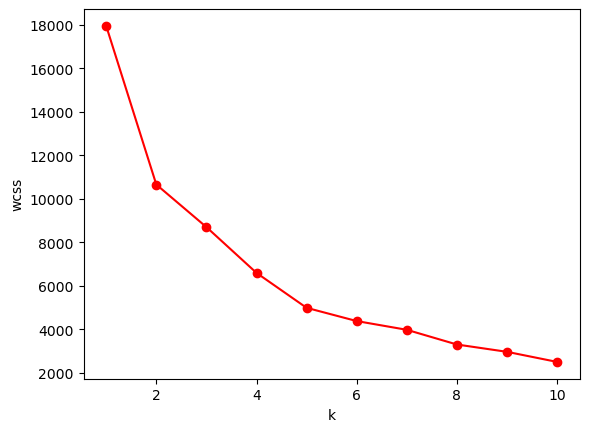

In [28]:
# plot

plt.plot(range(1,11), wcss , marker='o', color="red")
plt.xlabel("k")
plt.ylabel("wcss")

Text(0, 0.5, 'silhouette score')

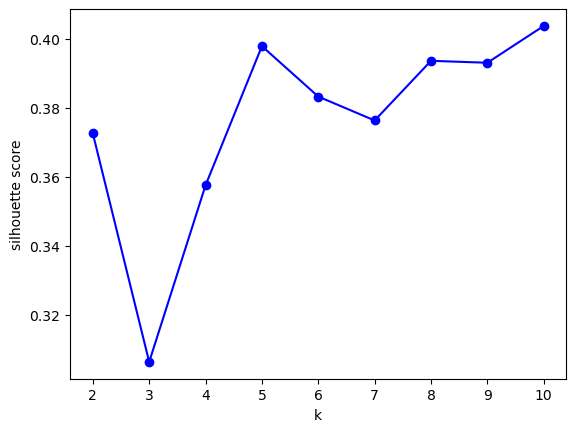

In [29]:
# 2. Silhouette Score
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca , labels)
    scores.append(score)

# plot

plt.plot(range(2,11), scores, marker='o',color="blue")
plt.xlabel("k")
plt.ylabel("silhouette score")

Text(0, 0.5, 'Silhouette Score')

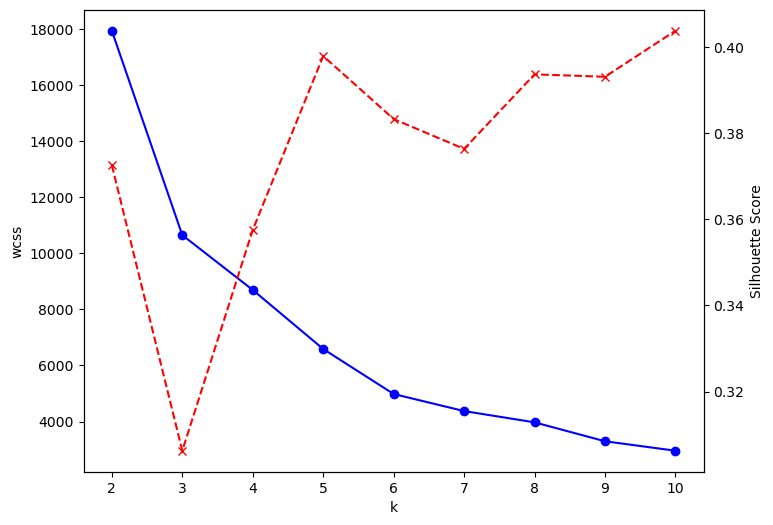

In [30]:
# combined plot

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize = (8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silhouette Score")

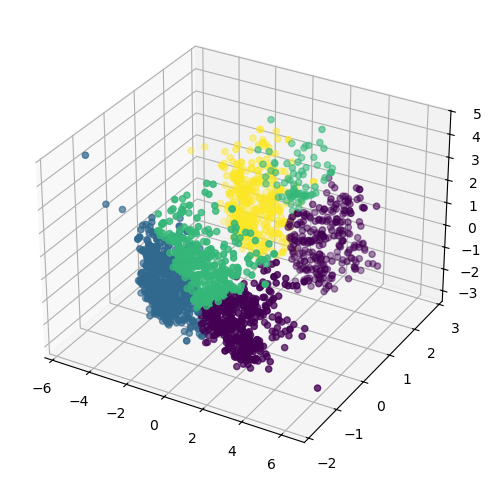

In [31]:
#Clustering

# k_means

kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmeans = kmeans.fit_predict(x_pca)
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c=labels_kmeans)

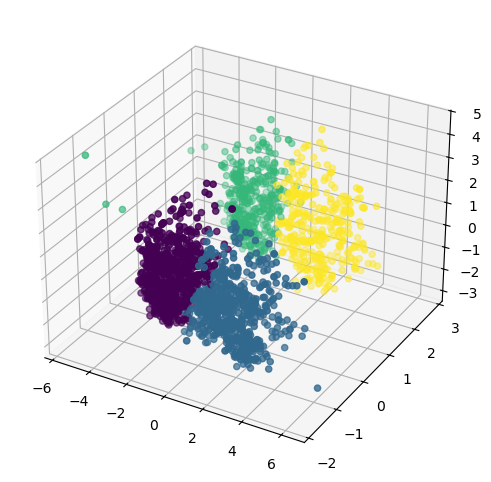

In [32]:
#Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters = 4 , linkage = "ward")
labels_agg = agg_clf.fit_predict(x_pca)
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(x_pca[:,0] , x_pca[:,1] , x_pca[:,2], c = labels_agg)

In [40]:
# Characterization of Clusters


X["cluster"] = labels_agg

X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

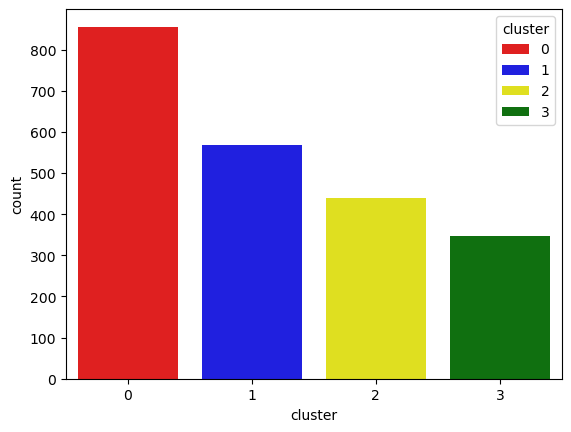

In [41]:
pal = ["red" , "blue" , "yellow" , "green"]

sns.countplot(x = X["cluster"], palette = pal , hue = X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

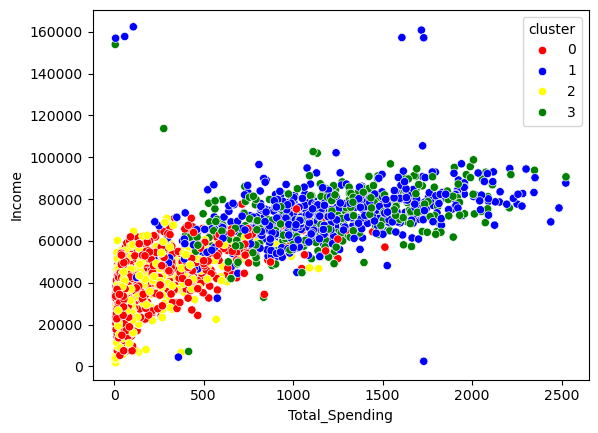

In [43]:
# Income & Spending Patterns

sns.scatterplot(x = X["Total_Spending"], y = X["Income"], hue=X["cluster"], palette = pal)

In [45]:
# Cluster Summart

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        38814.688084  49.113318           2.643692         3.063084   
1        71785.449912  48.810193           1.919156         5.662566   
2        36861.452273  48.034091           2.600000         2.736364   
3        71016.011527  50.380403           1.853026         5.749280   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.941589           4.070093           6.477804  0.009346   
1                   5.230228           8.469244           3.520211  0.008787   
2                   0.854545           3.643182           6.659091  0.011364   
3                   5.051873           8.466859           3.726225  0.005764   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         